In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [38]:
prices_day2 = pd.read_csv("../data/prices_round_5_day_2.csv", sep = ";")
prices_day3 = pd.read_csv("../data/prices_round_5_day_3.csv", sep = ";")
prices_day4 = pd.read_csv("../data/prices_round_5_day_4.csv", sep = ";")


trades_day2 = pd.read_csv("../data/trades_round_5_day_2.csv", sep = ";")
trades_day3 = pd.read_csv("../data/trades_round_5_day_3.csv", sep = ";")
trades_day4 = pd.read_csv("../data/trades_round_5_day_4.csv", sep = ";")

In [39]:
all_days_prices = pd.concat([prices_day2, prices_day3, prices_day4], axis = 0)
all_trades = pd.concat([trades_day2, trades_day3, trades_day4], axis = 0)

In [40]:
products_dict = {
    "Galaxy Sounds Recorders": [
        "GALAXY_SOUNDS_DARK_MATTER", 
        "GALAXY_SOUNDS_BLACK_HOLES", 
        "GALAXY_SOUNDS_PLANETARY_RINGS", 
        "GALAXY_SOUNDS_SOLAR_WINDS", 
        "GALAXY_SOUNDS_SOLAR_FLAMES"
    ],
    "Vertical Sleeping Pods": [
        "SLEEP_POD_SUEDE", 
        "SLEEP_POD_LAMB_WOOL", 
        "SLEEP_POD_POLYESTER", 
        "SLEEP_POD_NYLON", 
        "SLEEP_POD_COTTON"
    ],
    "Organic Microchips": [
        "MICROCHIP_CIRCLE", 
        "MICROCHIP_OVAL", 
        "MICROCHIP_SQUARE", 
        "MICROCHIP_RECTANGLE", 
        "MICROCHIP_TRIANGLE"
    ],
    "Purification Pebbles": [
        "PEBBLES_XS", 
        "PEBBLES_S", 
        "PEBBLES_M", 
        "PEBBLES_L", 
        "PEBBLES_XL"
    ],
    "Domestic Robots": [
        "ROBOT_VACUUMING", 
        "ROBOT_MOPPING", 
        "ROBOT_DISHES", 
        "ROBOT_LAUNDRY", 
        "ROBOT_IRONING"
    ],
    "UV-Visors": [
        "UV_VISOR_YELLOW", 
        "UV_VISOR_AMBER", 
        "UV_VISOR_ORANGE", 
        "UV_VISOR_RED", 
        "UV_VISOR_MAGENTA"
    ],
    "Instant Translators": [
        "TRANSLATOR_SPACE_GRAY", 
        "TRANSLATOR_ASTRO_BLACK", 
        "TRANSLATOR_ECLIPSE_CHARCOAL", 
        "TRANSLATOR_GRAPHITE_MIST", 
        "TRANSLATOR_VOID_BLUE"
    ],
    "Construction Panels": [
        "PANEL_1X2", 
        "PANEL_2X2", 
        "PANEL_1X4", 
        "PANEL_2X4", 
        "PANEL_4X4"
    ],
    "Liquid Breath Oxygen Shakes": [
        "OXYGEN_SHAKE_MORNING_BREATH", 
        "OXYGEN_SHAKE_EVENING_BREATH", 
        "OXYGEN_SHAKE_MINT", 
        "OXYGEN_SHAKE_CHOCOLATE", 
        "OXYGEN_SHAKE_GARLIC"
    ],
    "Protein Snack Packs": [
        "SNACKPACK_CHOCOLATE", 
        "SNACKPACK_VANILLA", 
        "SNACKPACK_PISTACHIO", 
        "SNACKPACK_STRAWBERRY", 
        "SNACKPACK_RASPBERRY"
    ]
}

--- Galaxy Sounds Recorders ---
--- Vertical Sleeping Pods ---
--- Organic Microchips ---
--- Purification Pebbles ---
--- Domestic Robots ---
--- UV-Visors ---
--- Instant Translators ---
--- Construction Panels ---
--- Liquid Breath Oxygen Shakes ---
--- Protein Snack Packs ---


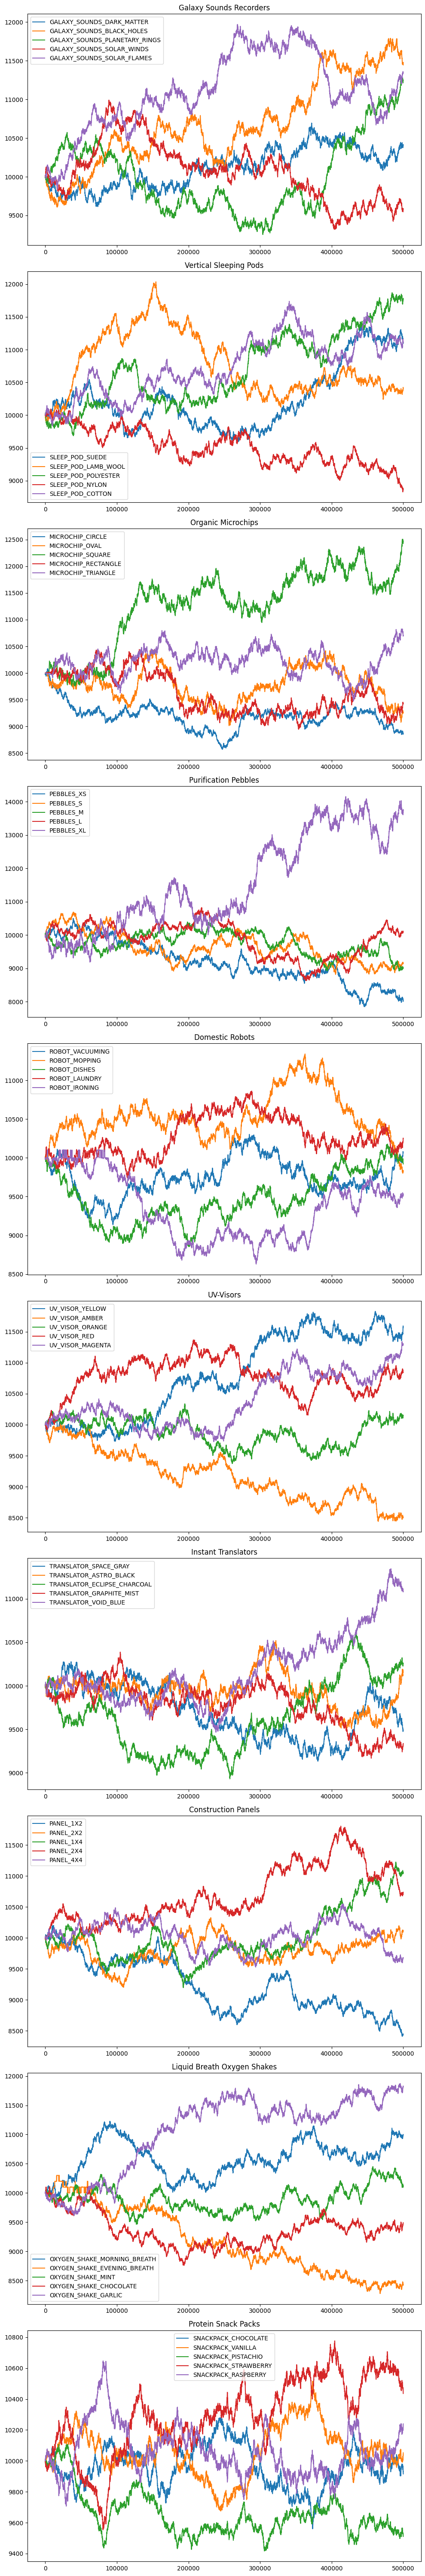

In [41]:
fig, ax = plt.subplots(len(products_dict), 1, figsize=(10, len(products_dict) * 6))
ax = ax.flatten()

day = 2

for i, basket in enumerate(products_dict.keys()):
    products = products_dict[basket]
    print(f"--- {basket} ---")
    
    for prod in products:
        day_price = all_days_prices[(all_days_prices["product"] == prod) & (all_days_prices["day"] == day)]["mid_price"]
        # Plotted the data
        ax[i].plot(day_price, label=f"{prod}")


        

    ax[i].set_title(f"{basket}")
    
    ax[i].legend()

plt.tight_layout() 
plt.show()

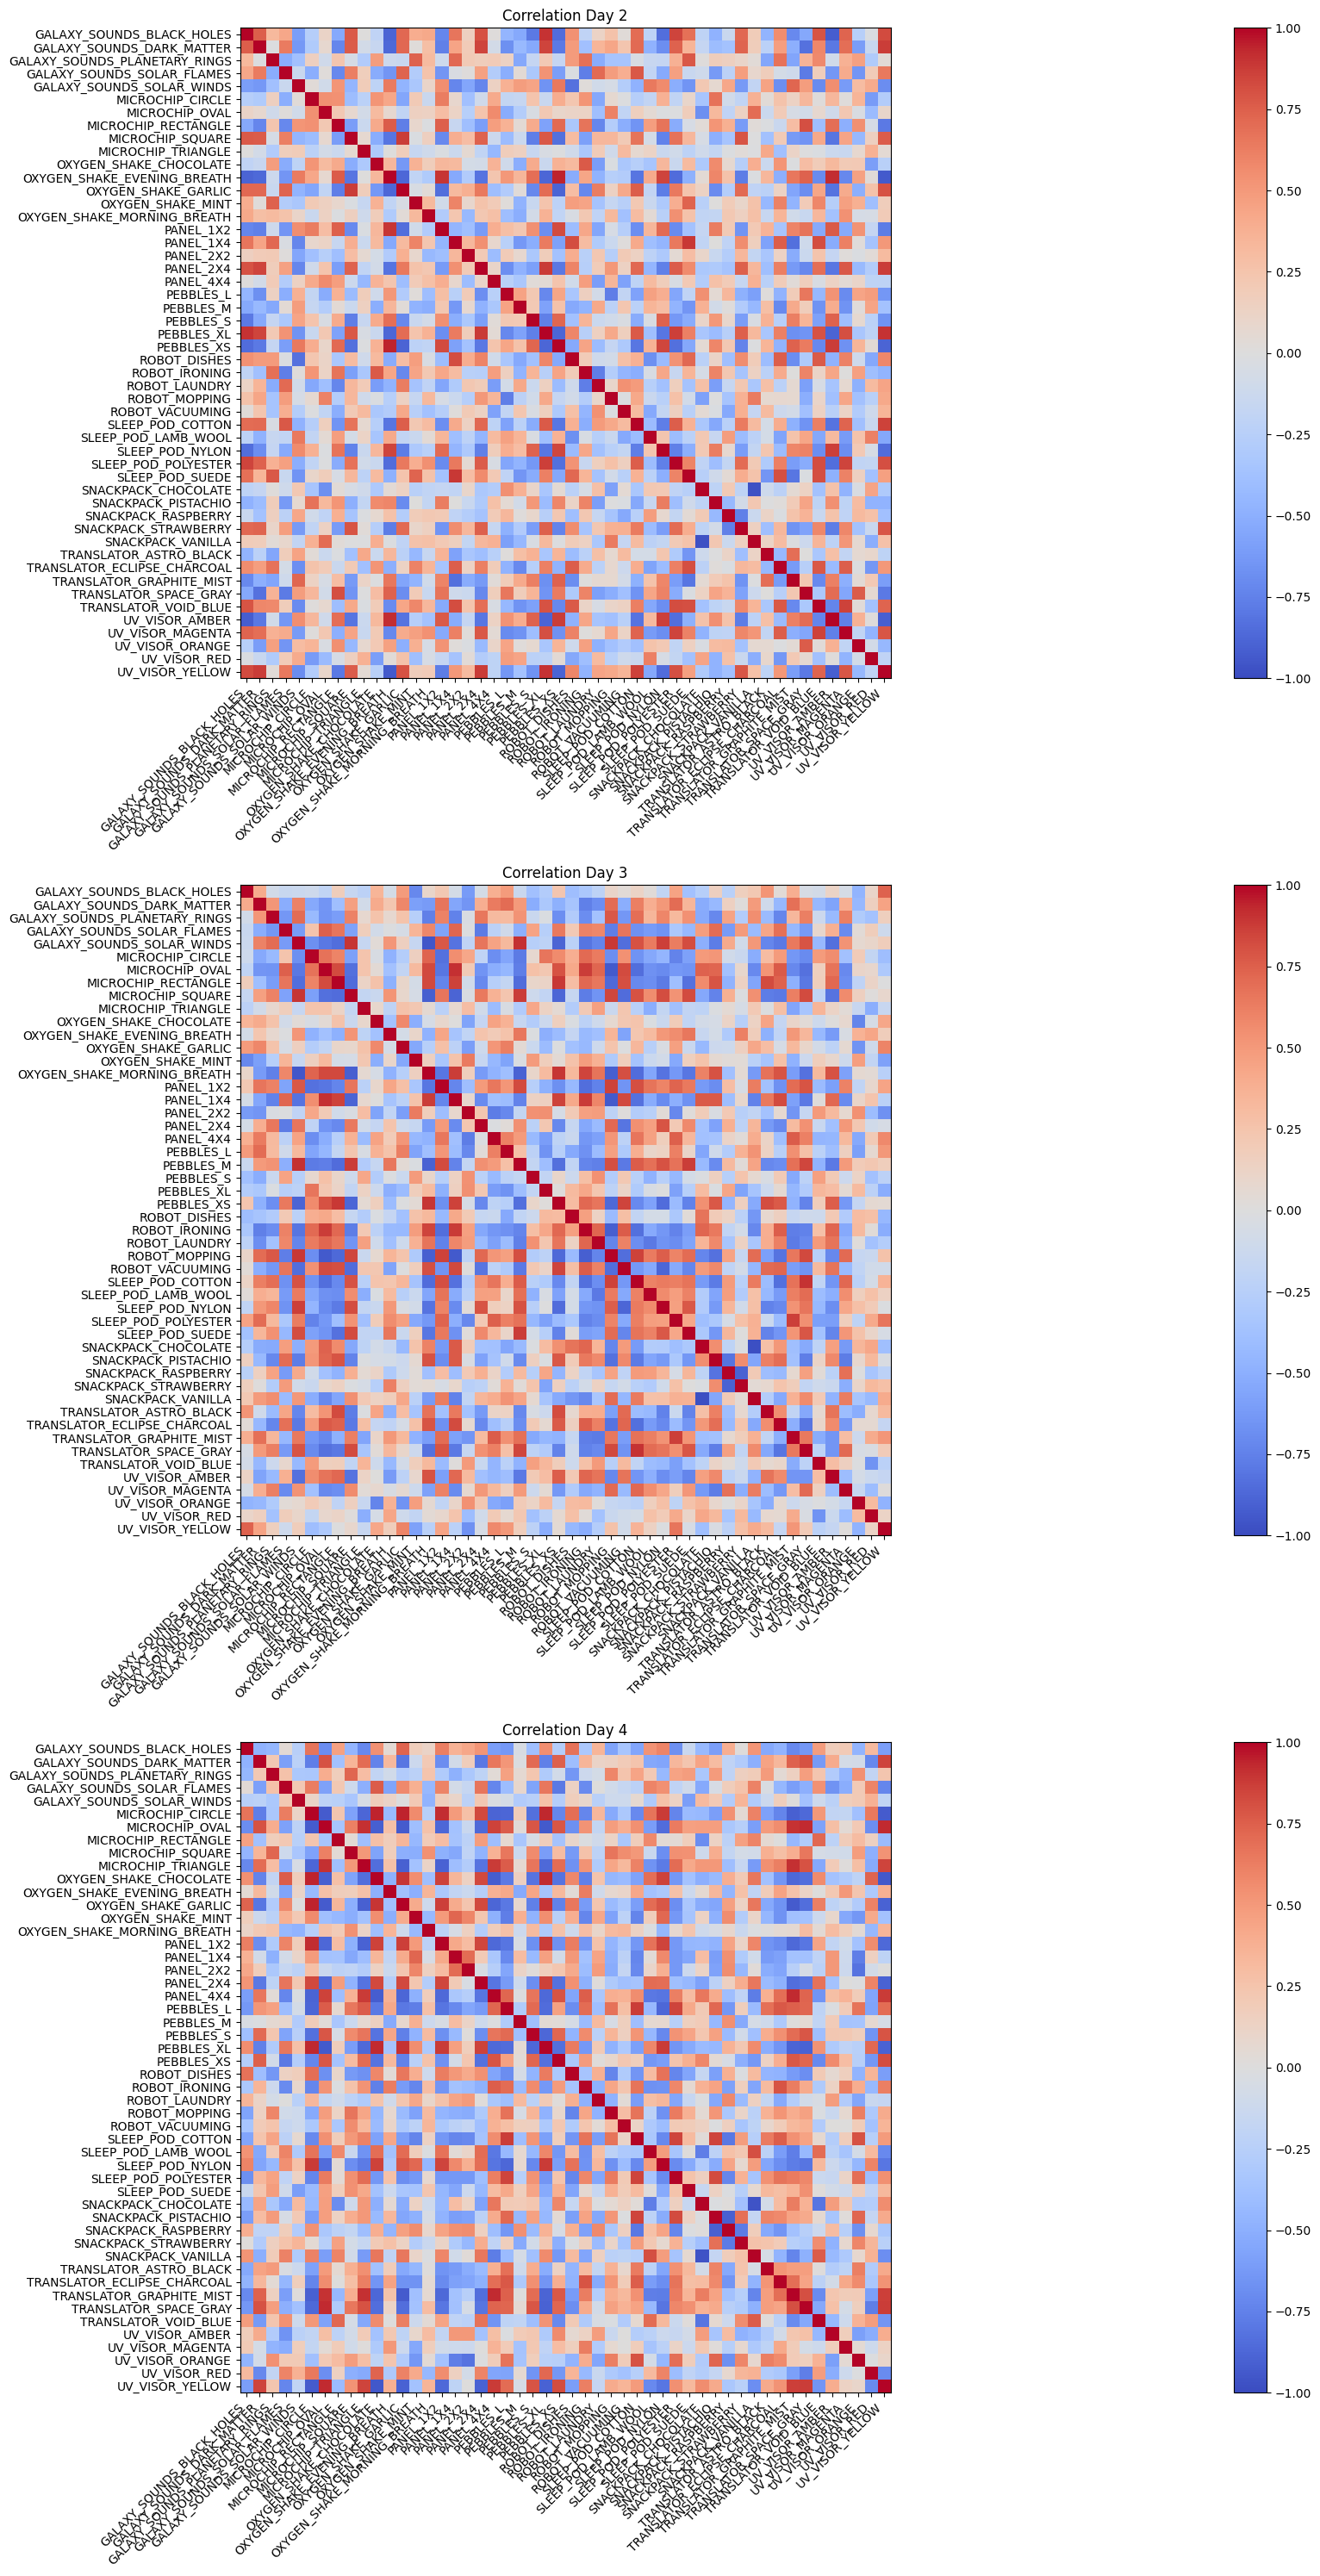

In [42]:
fig, ax = plt.subplots(len(range(2, 5)), 1, figsize=(100, 30))
ax = ax.flatten()

for i, day in enumerate(range(2, 5)):
    data_day = all_days_prices[all_days_prices["day"] == day]
    pivoted_data = data_day.pivot(index="timestamp", columns="product", values="mid_price")

    corr_matrix = pivoted_data.corr()
    
    im = ax[i].imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
    ax[i].set_title(f"Correlation Day {day}")
    
    ax[i].set_xticks(range(len(corr_matrix.columns)))
    ax[i].set_yticks(range(len(corr_matrix.index)))
    ax[i].set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
    ax[i].set_yticklabels(corr_matrix.index)
    
    fig.colorbar(im, ax=ax[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# COINTEGRATION ANALYSIS — STAT ARB
# ============================================================
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from itertools import combinations
import warnings, time
warnings.filterwarnings('ignore')

def build_price_matrix(prices_df):
    """Create monotonic timestamp across days, pivot to product columns, forward-fill."""
    dfs = []
    offset = 0
    for day in sorted(prices_df['day'].unique()):
        d = prices_df[prices_df['day'] == day].copy()
        d['global_ts'] = d['timestamp'] + offset
        offset += int(d['timestamp'].max()) + 1
        dfs.append(d)
    combined = pd.concat(dfs)
    pivot = combined.pivot_table(index='global_ts', columns='product', values='mid_price', aggfunc='mean')
    return pivot.ffill().dropna()

price_matrix = build_price_matrix(all_days_prices)
all_products = list(price_matrix.columns)
print(f"Price matrix: {price_matrix.shape[0]} timestamps x {price_matrix.shape[1]} products")
print(f"\nProducts ({len(all_products)}):")
for p in sorted(all_products):
    print(f"  {p}")

Price matrix: 30000 timestamps x 50 products

Products (50):
  GALAXY_SOUNDS_BLACK_HOLES
  GALAXY_SOUNDS_DARK_MATTER
  GALAXY_SOUNDS_PLANETARY_RINGS
  GALAXY_SOUNDS_SOLAR_FLAMES
  GALAXY_SOUNDS_SOLAR_WINDS
  MICROCHIP_CIRCLE
  MICROCHIP_OVAL
  MICROCHIP_RECTANGLE
  MICROCHIP_SQUARE
  MICROCHIP_TRIANGLE
  OXYGEN_SHAKE_CHOCOLATE
  OXYGEN_SHAKE_EVENING_BREATH
  OXYGEN_SHAKE_GARLIC
  OXYGEN_SHAKE_MINT
  OXYGEN_SHAKE_MORNING_BREATH
  PANEL_1X2
  PANEL_1X4
  PANEL_2X2
  PANEL_2X4
  PANEL_4X4
  PEBBLES_L
  PEBBLES_M
  PEBBLES_S
  PEBBLES_XL
  PEBBLES_XS
  ROBOT_DISHES
  ROBOT_IRONING
  ROBOT_LAUNDRY
  ROBOT_MOPPING
  ROBOT_VACUUMING
  SLEEP_POD_COTTON
  SLEEP_POD_LAMB_WOOL
  SLEEP_POD_NYLON
  SLEEP_POD_POLYESTER
  SLEEP_POD_SUEDE
  SNACKPACK_CHOCOLATE
  SNACKPACK_PISTACHIO
  SNACKPACK_RASPBERRY
  SNACKPACK_STRAWBERRY
  SNACKPACK_VANILLA
  TRANSLATOR_ASTRO_BLACK
  TRANSLATOR_ECLIPSE_CHARCOAL
  TRANSLATOR_GRAPHITE_MIST
  TRANSLATOR_SPACE_GRAY
  TRANSLATOR_VOID_BLUE
  UV_VISOR_AMBER
  UV_VISOR_M

In [44]:
# ============================================================
# ENGLE-GRANGER PAIRWISE COINTEGRATION — ALL PAIRS  C(50,2) = 1,225
# ============================================================
pairs = list(combinations(all_products, 2))
print(f"Testing {len(pairs):,} pairs with Engle-Granger...")

t0 = time.time()
pair_records = []
for p1, p2 in pairs:
    s1 = price_matrix[p1].values
    s2 = price_matrix[p2].values
    score, pval, _ = coint(s1, s2)
    pair_records.append({'asset1': p1, 'asset2': p2, 'eg_stat': score, 'eg_pval': pval})

pair_df = pd.DataFrame(pair_records).sort_values('eg_pval')
elapsed = time.time() - t0

sig5 = (pair_df['eg_pval'] < 0.05).sum()
sig1 = (pair_df['eg_pval'] < 0.01).sum()
print(f"Done in {elapsed:.1f}s  |  Significant at 5%: {sig5}  |  at 1%: {sig1}")

print(f"\nTop 30 most cointegrated pairs:")
print(pair_df[['asset1','asset2','eg_stat','eg_pval']].head(30).to_string(index=False))

# Within-basket vs cross-basket breakdown
def same_basket(p1, p2, pdict):
    for prods in pdict.values():
        if p1 in prods and p2 in prods:
            return True
    return False

pair_df['within_basket'] = pair_df.apply(
    lambda r: same_basket(r['asset1'], r['asset2'], products_dict), axis=1)
print(f"\nWithin-basket significant (5%): "
      f"{pair_df[pair_df['within_basket'] & (pair_df['eg_pval']<0.05)].shape[0]}")
print(f"Cross-basket significant (5%): "
      f"{pair_df[~pair_df['within_basket'] & (pair_df['eg_pval']<0.05)].shape[0]}")

print("\nTop 10 cross-basket cointegrated pairs:")
print(pair_df[~pair_df['within_basket']].head(10)[['asset1','asset2','eg_stat','eg_pval']].to_string(index=False))

Testing 1,225 pairs with Engle-Granger...
Done in 1223.7s  |  Significant at 5%: 62  |  at 1%: 22

Top 30 most cointegrated pairs:
                     asset1                      asset2   eg_stat  eg_pval
       SNACKPACK_STRAWBERRY              UV_VISOR_AMBER -4.476835 0.001337
  GALAXY_SOUNDS_DARK_MATTER             UV_VISOR_YELLOW -4.362378 0.002043
                  PANEL_2X4                  PEBBLES_XL -4.236858 0.003205
        SNACKPACK_RASPBERRY      TRANSLATOR_ASTRO_BLACK -4.175885 0.003967
        SNACKPACK_RASPBERRY             UV_VISOR_ORANGE -4.154201 0.004275
        SNACKPACK_RASPBERRY             UV_VISOR_YELLOW -4.145967 0.004398
        SNACKPACK_RASPBERRY TRANSLATOR_ECLIPSE_CHARCOAL -4.123762 0.004745
OXYGEN_SHAKE_MORNING_BREATH                   PEBBLES_M -4.096281 0.005210
        SLEEP_POD_POLYESTER        SNACKPACK_STRAWBERRY -4.094870 0.005235
        SNACKPACK_RASPBERRY    TRANSLATOR_GRAPHITE_MIST -4.068265 0.005726
                 PEBBLES_XL                R

In [ ]:
pair_df[pairs].to_csv('pair_coint.csv')

In [45]:
# ============================================================
# JOHANSEN COINTEGRATION — ALL TRIPLETS  C(50,3) = 19,600
# ============================================================
triplets = list(combinations(all_products, 3))
print(f"Testing {len(triplets):,} triplets with Johansen trace test...")

t0 = time.time()
triplet_records = []
for idx, combo in enumerate(triplets):
    mat = price_matrix[list(combo)].values
    try:
        res = coint_johansen(mat, 0, 1)
        rank = int((res.lr1 > res.cvt[:, 1]).sum())
        ts0, cv0, evec = float(res.lr1[0]), float(res.cvt[0, 1]), res.evec[:, 0]
    except Exception:
        rank, ts0, cv0, evec = 0, np.nan, np.nan, None
    triplet_records.append({
        'assets': combo, 'rank': rank,
        'trace_stat': ts0, 'crit_95': cv0,
        'cointegrated': rank >= 1, 'evec': evec
    })
    if (idx + 1) % 5000 == 0:
        print(f"  {idx+1:>6}/{len(triplets)}  elapsed={time.time()-t0:.1f}s")

triplet_df = pd.DataFrame(triplet_records).sort_values('trace_stat', ascending=False)
elapsed = time.time() - t0
sig_t = triplet_df['cointegrated'].sum()
print(f"\nDone in {elapsed:.1f}s  |  Cointegrated (rank≥1, 95%): {sig_t:,}/{len(triplets):,}")

print(f"\nTop 20 cointegrated triplets:")
print(triplet_df[['assets','rank','trace_stat','crit_95']].head(20).to_string(index=False))

# Basket breakdown
print("\nCointegrated triplets by basket (within-basket only):")
for bname, bprods in products_dict.items():
    bset = set(bprods)
    sub = triplet_df[triplet_df['assets'].apply(lambda a: all(x in bset for x in a))]
    sig = sub['cointegrated'].sum()
    print(f"  {bname:<35}: {sig}/{len(sub)}")

Testing 19,600 triplets with Johansen trace test...
    5000/19600  elapsed=21.7s
   10000/19600  elapsed=44.7s
   15000/19600  elapsed=67.3s

Done in 85.9s  |  Cointegrated (rank≥1, 95%): 3,072/19,600

Top 20 cointegrated triplets:
                                                                         assets  rank  trace_stat  crit_95
                           (GALAXY_SOUNDS_BLACK_HOLES, PEBBLES_S, ROBOT_DISHES)     2   49.261064  29.7961
                (MICROCHIP_CIRCLE, OXYGEN_SHAKE_CHOCOLATE, SNACKPACK_CHOCOLATE)     2   48.887422  29.7961
                  (MICROCHIP_CIRCLE, OXYGEN_SHAKE_CHOCOLATE, SNACKPACK_VANILLA)     2   48.462923  29.7961
(OXYGEN_SHAKE_EVENING_BREATH, SLEEP_POD_LAMB_WOOL, TRANSLATOR_ECLIPSE_CHARCOAL)     3   48.182679  29.7961
                   (MICROCHIP_CIRCLE, OXYGEN_SHAKE_CHOCOLATE, SLEEP_POD_COTTON)     3   47.733521  29.7961
                      (ROBOT_DISHES, SNACKPACK_PISTACHIO, SNACKPACK_STRAWBERRY)     3   46.789882  29.7961
                  

In [52]:
triplet_df.to_csv("triplet_coint.csv")

In [46]:
# ============================================================
# JOHANSEN COINTEGRATION — QUARTETS
# Strategy: within-basket C(5,4) + extend significant triplets with every other asset
# (avoids the 230k brute-force while covering the most promising cross-basket combos)
# ============================================================

def johansen_rank(mat, det_order=0, k_ar_diff=1):
    """Returns (rank, trace_stat_H0, crit_95_H0, first_cointegrating_eigenvector)."""
    try:
        res = coint_johansen(mat, det_order, k_ar_diff)
        rank = int((res.lr1 > res.cvt[:, 1]).sum())
        return rank, float(res.lr1[0]), float(res.cvt[0, 1]), res.evec[:, 0]
    except Exception:
        return 0, np.nan, np.nan, None

# Build candidate set
within_quartets = set()
for prods in products_dict.values():
    avail = [p for p in prods if p in price_matrix.columns]
    for combo in combinations(avail, 4):
        within_quartets.add(tuple(sorted(combo)))

sig_triplets = [row['assets'] for _, row in triplet_df[triplet_df['cointegrated']].iterrows()]
extended_quartets = set()
for tri in sig_triplets:
    tri_set = set(tri)
    for p in all_products:
        if p not in tri_set:
            extended_quartets.add(tuple(sorted(list(tri) + [p])))

all_quartets = list(within_quartets | extended_quartets)
print(f"Quartets to test: {len(all_quartets):,}  "
      f"(within-basket: {len(within_quartets)}, extended: {len(extended_quartets)})")

t0 = time.time()
quartet_records = []
for combo in all_quartets:
    mat = price_matrix[list(combo)].values
    rank, ts0, cv0, evec = johansen_rank(mat)
    quartet_records.append({
        'assets': combo, 'rank': rank,
        'trace_stat': ts0, 'crit_95': cv0,
        'cointegrated': rank >= 1, 'evec': evec
    })

quartet_df = pd.DataFrame(quartet_records).sort_values('trace_stat', ascending=False)
elapsed = time.time() - t0
sig_q = quartet_df['cointegrated'].sum()
print(f"Done in {elapsed:.1f}s  |  Cointegrated (rank≥1, 95%): {sig_q}/{len(all_quartets)}")

print(f"\nTop 20 cointegrated quartets:")
print(quartet_df[['assets','rank','trace_stat','crit_95']].head(20).to_string(index=False))

# Basket breakdown
print("\nCointegrated quartets by basket:")
for bname, bprods in products_dict.items():
    bset = set(bprods)
    sub = quartet_df[quartet_df['assets'].apply(lambda a: all(x in bset for x in a))]
    sig = sub['cointegrated'].sum()
    print(f"  {bname:<35}: {sig}/{len(sub)}")

Quartets to test: 91,263  (within-basket: 50, extended: 91229)
Done in 439.4s  |  Cointegrated (rank≥1, 95%): 29771/91263

Top 20 cointegrated quartets:
                                                                                       assets  rank  trace_stat  crit_95
            (MICROCHIP_CIRCLE, OXYGEN_SHAKE_CHOCOLATE, SLEEP_POD_COTTON, SNACKPACK_CHOCOLATE)     4   81.063089  47.8545
              (MICROCHIP_CIRCLE, OXYGEN_SHAKE_CHOCOLATE, SLEEP_POD_COTTON, SNACKPACK_VANILLA)     4   79.130335  47.8545
                                        (PANEL_2X4, PEBBLES_XS, ROBOT_DISHES, UV_VISOR_AMBER)     1   75.386710  47.8545
                       (ROBOT_DISHES, SLEEP_POD_SUEDE, TRANSLATOR_SPACE_GRAY, UV_VISOR_AMBER)     2   75.280584  47.8545
                   (MICROCHIP_SQUARE, SLEEP_POD_SUEDE, TRANSLATOR_SPACE_GRAY, UV_VISOR_AMBER)     1   74.389474  47.8545
                            (GALAXY_SOUNDS_SOLAR_FLAMES, PANEL_2X4, PEBBLES_XL, ROBOT_DISHES)     2   73.704503  47.8545


In [53]:
quartet_df.to_csv("quartet_coint.csv")

In [48]:
# ============================================================
# SPREAD STATIONARITY: ADF + HALF-LIFE (top pairs/triplets/quartets)
# ============================================================

def eg_spread(p1, p2, pm):
    """Engle-Granger residual: OLS y ~ x then residuals."""
    x = pm[p1].values
    y = pm[p2].values
    X = np.column_stack([x, np.ones(len(x))])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    return y - X @ beta

def johansen_spread(assets, evec, pm):
    """Linear combo via first Johansen eigenvector."""
    return pm[list(assets)].values @ evec

def spread_stats(spread):
    """ADF test + AR(1) half-life."""
    adf_res = adfuller(spread, maxlag=10, autolag='AIC')
    adf_stat, adf_pval = adf_res[0], adf_res[1]
    # AR(1): delta_S = lambda * S_{t-1} + eps  →  HL = -ln2 / lambda
    lag = spread[:-1]
    diff = np.diff(spread)
    X = np.column_stack([lag, np.ones(len(lag))])
    lam = np.linalg.lstsq(X, diff, rcond=None)[0][0]
    half_life = -np.log(2) / lam if lam < 0 else np.inf
    return adf_stat, adf_pval, half_life

spread_records = []

# --- Top 100 pairs (Engle-Granger spread) ---
for _, row in pair_df.head(100).iterrows():
    spread = eg_spread(row['asset1'], row['asset2'], price_matrix)
    s, p, hl = spread_stats(spread)
    spread_records.append({
        'type': 'pair', 'assets': (row['asset1'], row['asset2']),
        'coint_pval': row['eg_pval'], 'adf_stat': s, 'adf_pval': p, 'half_life': hl, 'spread': spread
    })

# --- Top 50 triplets (Johansen first eigenvector) ---
for _, row in triplet_df[triplet_df['cointegrated']].head(50).iterrows():
    if row['evec'] is not None:
        spread = johansen_spread(row['assets'], row['evec'], price_matrix)
        s, p, hl = spread_stats(spread)
        spread_records.append({
            'type': 'triplet', 'assets': row['assets'],
            'coint_pval': np.nan, 'adf_stat': s, 'adf_pval': p, 'half_life': hl, 'spread': spread
        })

# --- Top 30 quartets (Johansen first eigenvector) ---
for _, row in quartet_df[quartet_df['cointegrated']].head(30).iterrows():
    if row['evec'] is not None:
        spread = johansen_spread(row['assets'], row['evec'], price_matrix)
        s, p, hl = spread_stats(spread)
        spread_records.append({
            'type': 'quartet', 'assets': row['assets'],
            'coint_pval': np.nan, 'adf_stat': s, 'adf_pval': p, 'half_life': hl, 'spread': spread
        })

spread_df = pd.DataFrame(spread_records).sort_values('adf_stat')
print(f"Spreads computed: {len(spread_df)} total")
print(f"  Pairs    : {(spread_df['type']=='pair').sum()}")
print(f"  Triplets : {(spread_df['type']=='triplet').sum()}")
print(f"  Quartets : {(spread_df['type']=='quartet').sum()}")
print(f"\nADF p<5%  : {(spread_df['adf_pval']<0.05).sum()}")
print(f"ADF p<1%  : {(spread_df['adf_pval']<0.01).sum()}")
print(f"\nTop 20 by ADF statistic:")
print(spread_df[['type','assets','adf_stat','adf_pval','half_life']].head(20).to_string(index=False))

Spreads computed: 180 total
  Pairs    : 100
  Triplets : 50
  Quartets : 30

ADF p<5%  : 148
ADF p<1%  : 121

Top 20 by ADF statistic:
   type                                                                         assets  adf_stat     adf_pval  half_life
quartet                   (PEBBLES_S, PEBBLES_XL, TRANSLATOR_SPACE_GRAY, UV_VISOR_RED) -6.138256 8.087867e-08 294.541888
quartet (OXYGEN_SHAKE_CHOCOLATE, PANEL_1X2, SNACKPACK_CHOCOLATE, TRANSLATOR_VOID_BLUE) -6.103199 9.723528e-08 264.725594
triplet                                  (PEBBLES_M, PEBBLES_XS, TRANSLATOR_VOID_BLUE) -6.017104 1.524436e-07 292.477653
quartet                          (PANEL_2X4, PEBBLES_XS, ROBOT_DISHES, UV_VISOR_AMBER) -5.653743 9.727107e-07 268.697662
quartet                   (PANEL_2X4, PEBBLES_XS, SNACKPACK_RASPBERRY, UV_VISOR_AMBER) -5.217086 8.112700e-06 378.680348
quartet                 (MICROCHIP_TRIANGLE, PANEL_1X2, ROBOT_DISHES, SLEEP_POD_NYLON) -5.181546 9.587691e-06 257.168639
quartet       (GA

In [ ]:
spread_df.to_csv('spread_df.csv')

,type,assets,coint_pval,adf_stat,adf_pval,half_life,spread
161,quartet,"(PEBBLES_S, PEBBLES_XL, TRANSLATOR_SPACE_GRAY,...",NaN,-6.138256,8.087867e-08,294.541888,"[108.83170178678272, 108.83367703419965, 108.8..."
159,quartet,"(OXYGEN_SHAKE_CHOCOLATE, PANEL_1X2, SNACKPACK_...",NaN,-6.103199,9.723528e-08,264.725594,"[-127.32606963551979, -127.41034485342671, -12..."
106,triplet,"(PEBBLES_M, PEBBLES_XS, TRANSLATOR_VOID_BLUE)",NaN,-6.017104,1.524436e-07,292.477653,"[89.31875766190946, 89.40786469793925, 89.5140..."
152,quartet,"(PANEL_2X4, PEBBLES_XS, ROBOT_DISHES, UV_VISOR...",NaN,-5.653743,9.727107e-07,268.697662,"[-6.154438175458321, -6.100210282178131, -6.08..."
175,quartet,"(PANEL_2X4, PEBBLES_XS, SNACKPACK_RASPBERRY, U...",NaN,-5.217086,8.112700e-06,378.680348,"[48.15673066048617, 48.19253842203484, 48.2295..."
...,...,...,...,...,...,...,...
5,pair,"(SNACKPACK_RASPBERRY, UV_VISOR_YELLOW)",0.004398,-1.811596,3.747199e-01,3456.307033,"[-1017.4768004018624, -1023.7346784360707, -10..."
76,pair,"(SNACKPACK_VANILLA, TRANSLATOR_SPACE_GRAY)",0.061514,-1.803437,3.787566e-01,2892.859975,"[482.91071590909814, 477.7200266193704, 480.59..."
18,pair,"(SNACKPACK_RASPBERRY, TRANSLATOR_VOID_BLUE)",0.006980,-1.712662,4.246009e-01,3712.277832,"[-862.7966554851591, -859.9985619782165, -855...."
4,pair,"(SNACKPACK_RASPBERRY, UV_VISOR_ORANGE)",0.004275,-1.551256,5.080210e-01,3642.692287,"[-473.5642545736464, -466.73804541900245, -456..."


Total spreads analyzed: 180
Stationary (ADF p<5%) with tradeable half-life (0–500 ticks): 60


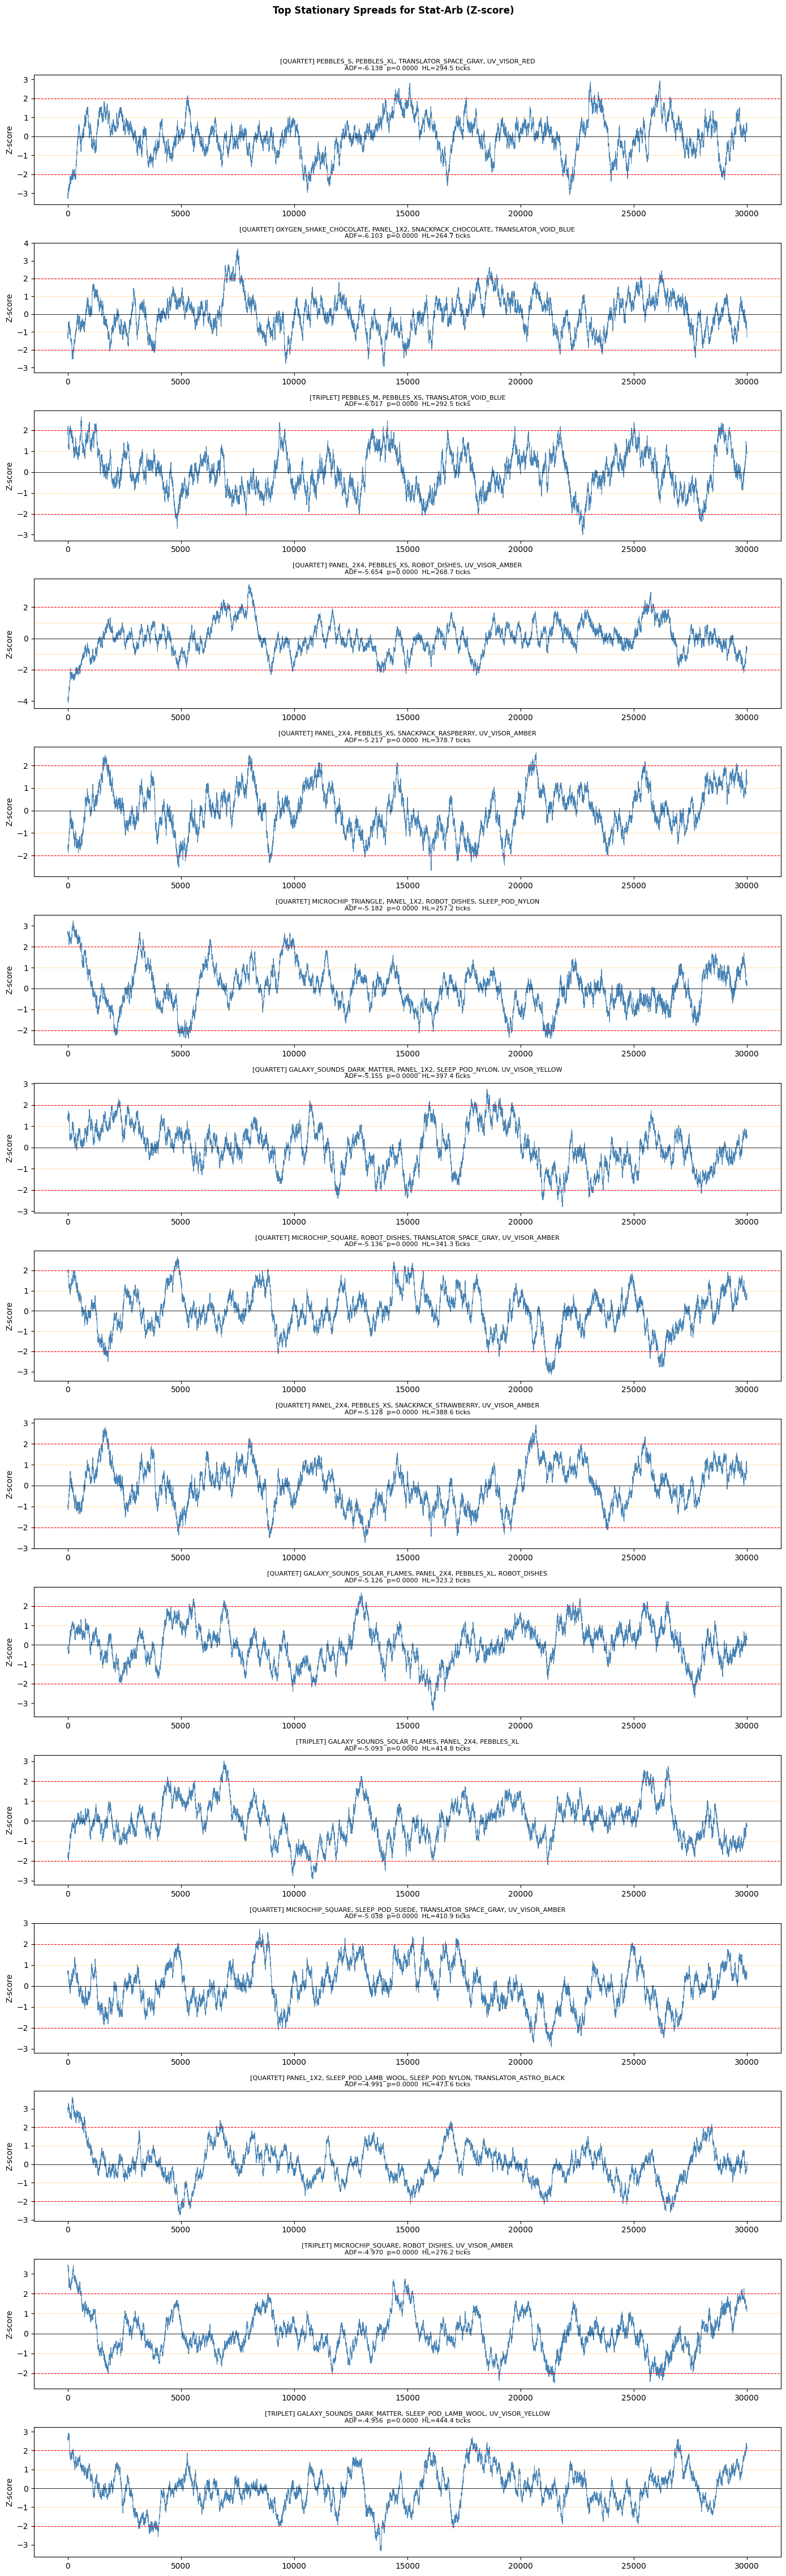


=== STAT-ARB SUMMARY TABLE ===
Type       ADF Stat  ADF p-val  Half-Life  Assets
--------------------------------------------------------------------------------------------------------------
quartet      -6.138     0.0000      294.5  PEBBLES_S, PEBBLES_XL, TRANSLATOR_SPACE_GRAY, UV_VISOR_RED
quartet      -6.103     0.0000      264.7  OXYGEN_SHAKE_CHOCOLATE, PANEL_1X2, SNACKPACK_CHOCOLATE, TRANSLATOR_VOID_BLUE
triplet      -6.017     0.0000      292.5  PEBBLES_M, PEBBLES_XS, TRANSLATOR_VOID_BLUE
quartet      -5.654     0.0000      268.7  PANEL_2X4, PEBBLES_XS, ROBOT_DISHES, UV_VISOR_AMBER
quartet      -5.217     0.0000      378.7  PANEL_2X4, PEBBLES_XS, SNACKPACK_RASPBERRY, UV_VISOR_AMBER
quartet      -5.182     0.0000      257.2  MICROCHIP_TRIANGLE, PANEL_1X2, ROBOT_DISHES, SLEEP_POD_NYLON
quartet      -5.155     0.0000      397.4  GALAXY_SOUNDS_DARK_MATTER, PANEL_1X2, SLEEP_POD_NYLON, UV_VISOR_YELLOW
quartet      -5.136     0.0000      341.3  MICROCHIP_SQUARE, ROBOT_DISHES, TRANSLAT

In [49]:
# ============================================================
# PLOT TOP STATIONARY SPREADS + SUMMARY TABLE
# ============================================================
tradeable = spread_df[
    (spread_df['adf_pval'] < 0.05) &
    (spread_df['half_life'] > 0) &
    (spread_df['half_life'] < 500)
].copy()

print(f"Total spreads analyzed: {len(spread_df)}")
print(f"Stationary (ADF p<5%) with tradeable half-life (0–500 ticks): {len(tradeable)}")

top_n = min(15, len(tradeable))
if top_n == 0:
    print("No tradeable spreads found.")
else:
    fig, axes = plt.subplots(top_n, 1, figsize=(14, top_n * 3))
    if top_n == 1:
        axes = [axes]

    for i, (_, row) in enumerate(tradeable.head(top_n).iterrows()):
        spread = row['spread']
        z = (spread - spread.mean()) / spread.std()
        axes[i].plot(z, linewidth=0.7, color='steelblue')
        axes[i].axhline(0,  color='black',  linewidth=0.6)
        axes[i].axhline( 2, color='red',    linestyle='--', linewidth=0.8)
        axes[i].axhline(-2, color='red',    linestyle='--', linewidth=0.8)
        axes[i].axhline( 1, color='orange', linestyle=':',  linewidth=0.6)
        axes[i].axhline(-1, color='orange', linestyle=':',  linewidth=0.6)
        title = (f"[{row['type'].upper()}] {', '.join(row['assets'])}\n"
                 f"ADF={row['adf_stat']:.3f}  p={row['adf_pval']:.4f}  "
                 f"HL={row['half_life']:.1f} ticks")
        axes[i].set_title(title, fontsize=8)
        axes[i].set_ylabel("Z-score")

    plt.suptitle("Top Stationary Spreads for Stat-Arb (Z-score)", y=1.01, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n=== STAT-ARB SUMMARY TABLE ===")
print(f"{'Type':<8} {'ADF Stat':>10} {'ADF p-val':>10} {'Half-Life':>10}  Assets")
print("-" * 110)
for _, row in tradeable.head(30).iterrows():
    assets_str = ', '.join(row['assets'])[:80]
    print(f"{row['type']:<8} {row['adf_stat']:>10.3f} {row['adf_pval']:>10.4f} {row['half_life']:>10.1f}  {assets_str}")